# M1: behavioral-vs-EEG overlap

`PLANssvepvsBeh.md` M1: both the behavioral (manual) and EEG (SSVEP grid)
tasks probe the same construct -- the "metamer," the (red, green) mix that
looks the same as the fixed yellow reference. Behaviorally it's a direct
click; on the EEG grid it's (hypothesized to be) the point of minimal SSVEP
amplitude. See `docs/experiment_summary.md` for the full experimental
context.

This notebook runs **three independent kinds of check**, deliberately not
just one test run three ways, since the point is to justify the EEG test
against behavior as convincingly as the data allows:

1. **Spatial overlap** (`weighted_overlap_test`) -- do a participant's/
   group's clicks concentrate where the EEG response is low?
2. **A second, differently-constructed spatial test** (`click_value_test`)
   -- same question, but with a random-cell null instead of a toroidal
   shift, so agreement between the two isn't circular.
3. **Individual-differences correlation** (`correlation.py`) -- across
   subjects, does EEG-derived severity track behavioral severity? This is
   the one the first two can't answer: overlap can be significant in every
   group without the *degree* of deficiency correlating at all.

**Orientation bug found and fixed while building this**: the template
(`templateCode/grid_mapping.py`)'s `outMat` return value is
`[green_idx, red_idx]` -- the same axis-swap bug `ssveps/` already found and
fixed once (`docs/ssvep_summary.md` finding 2.1). `scripts/overlap.py`
builds its behavioral density map from the untransposed indices instead, so
it's genuinely `[red_idx, green_idx]` like every `ssveps/` grid -- pinned by
a regression test (`tests/test_ssvepbeh.py`). Both permutation tests also
apply the `(1 + count) / (1 + n_perm)` p-value correction
`docs/ssvep_summary.md` finding 2.7 flagged as still-missing in
`ssveps/scripts/permutation.py` itself -- a permutation p-value can never
legitimately be exactly 0.

In [1]:
import sys
sys.path.append('../../beh/scripts')
sys.path.append('../scripts')

import numpy as np
import pandas as pd

import loader as beh_loader
import overlap

# overlap's own import above inserts ssveps/scripts at sys.path[0] (it needs
# ssveps' analysis.py) -- ssveps/scripts has its own plotting.py too, so
# re-assert this project's scripts/ first before resolving "plotting", or it
# would silently import ssveps' version instead (see overlap.py's docstring).
sys.path.insert(0, '../scripts')
import plotting
import correlation

analysis = overlap.analysis  # ssveps/scripts/analysis.py, imported by overlap.py

beh_df = beh_loader.load_behavioral()
runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()

session = 1
overlap_subs = sorted(set(beh_df['sub_id']) & set(metadata_df.loc[metadata_df['session'] == session, 'sub_id']))
print(f"{len(overlap_subs)} subjects have both behavioral and session-{session} EEG data")

categories = [
    ('HC', dict(group='CTR')),
    ('PD', dict(group='PD')),
    ('CVD', dict(group='CVD')),
    ('protan', dict(group='CVD', subgroup='protan')),
    ('deutan', dict(group='CVD', subgroup='deutan')),
]

43 subjects have both behavioral and session-1 EEG data


## One participant: EEG response vs. behavioral click density

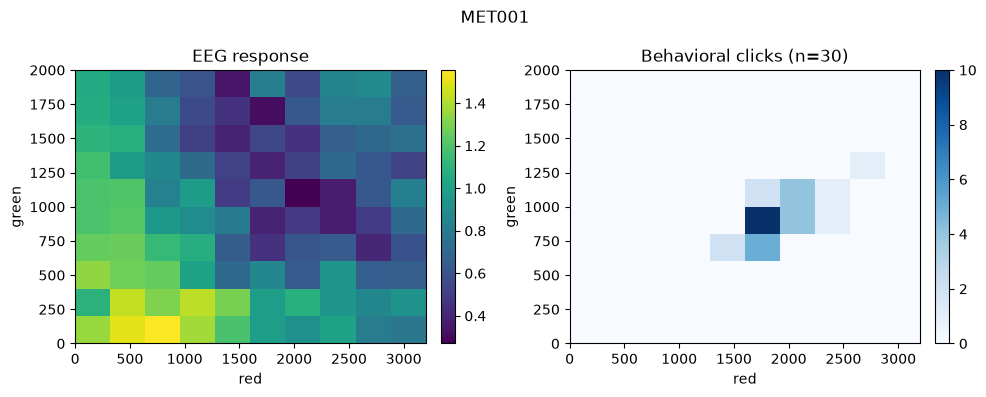

In [2]:
sub_id = 'MET001'
E = analysis.mean_grid(runmap_df, baselines_df, sub_id, session, normalize=analysis.DEFAULT_NORMALIZE)
plotting.plot_overlap(beh_df, E, [sub_id], title=sub_id);

In [3]:
overlap.subject_overlap(beh_df, runmap_df, baselines_df, sub_id, session, n_perm=5000, seed=0)

{'p_value': 0.009998000399920015,
 'obs_stat': 0.4384506989369529,
 'null_stats': array([1.11714066, 1.06151137, 0.63323125, ..., 1.23533762, 0.6661433 ,
        0.61778085], shape=(5000,))}

## 1 & 2. Spatial overlap: every group, both tests

Each group's clicks pooled into one density map, EEG grids averaged
(`mean_grid_across_subjects`) into one response map, one test per group.
`weighted_overlap_test` (toroidal-shift null) and `click_value_test`
(random-cell null) are run side by side -- two different constructions of
"do clicks land where EEG is low," so their agreement is real corroboration,
not the same computation twice.

In [4]:
rows = []
for label, kw in categories:
    r1 = overlap.group_overlap(beh_df, runmap_df, baselines_df, metadata_df, session, n_perm=5000, seed=0, **kw)
    r2 = overlap.group_click_value_test(beh_df, runmap_df, baselines_df, metadata_df, session, n_perm=5000, seed=0, **kw)
    rows.append({'group': label, 'n': r1['n_subjects'], 'weighted_overlap_p': r1['p_value'], 'click_value_p': r2['p_value']})
group_results = pd.DataFrame(rows)
group_results

,group,n,weighted_overlap_p,click_value_p
0,HC,21,0.009998,0.0002
1,PD,6,0.040992,0.0002
2,CVD,15,0.020996,0.0002
3,protan,8,0.020996,0.0002
4,deutan,7,0.009998,0.0002


**Every group is significant on both tests** (p<0.05 throughout, `click_value_test`
pegged at its floor of 1/(n_perm+1) for every group) -- the two independent
constructions agree completely. That's strong evidence the spatial
overlap finding is real, not an artifact of one particular null model.

## Group heatmaps: EEG response vs. behavioral density, all five groups

`01_explore`'s first version only showed this for HC -- extended here to
PD, CVD, protan, and deutan too, so the shape of the agreement (not just
its p-value) is visible for every group.

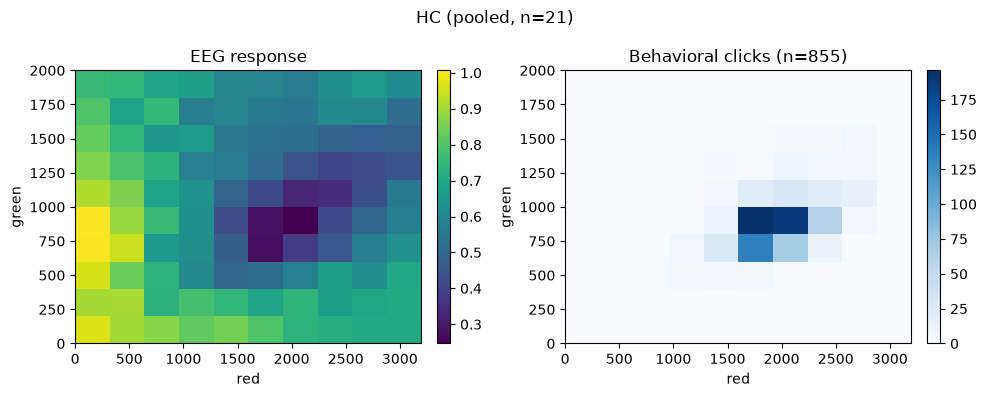

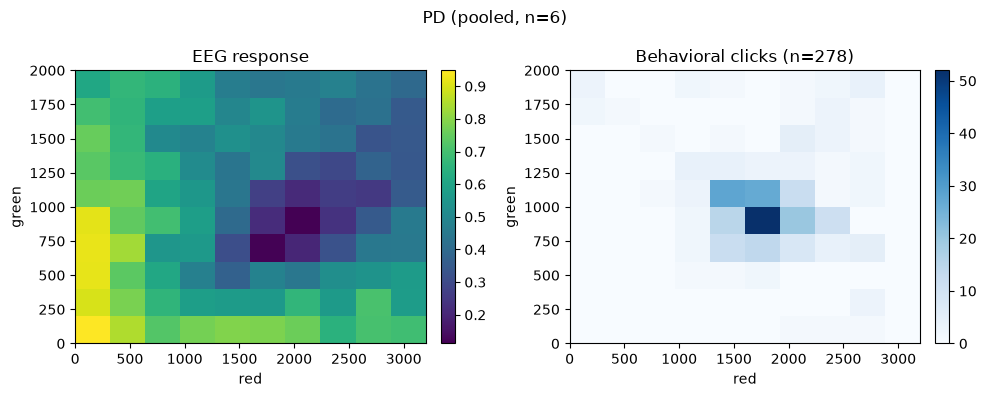

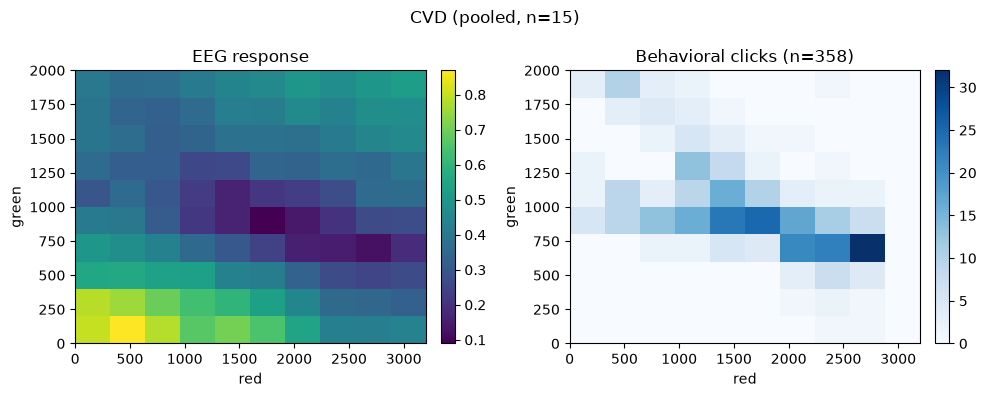

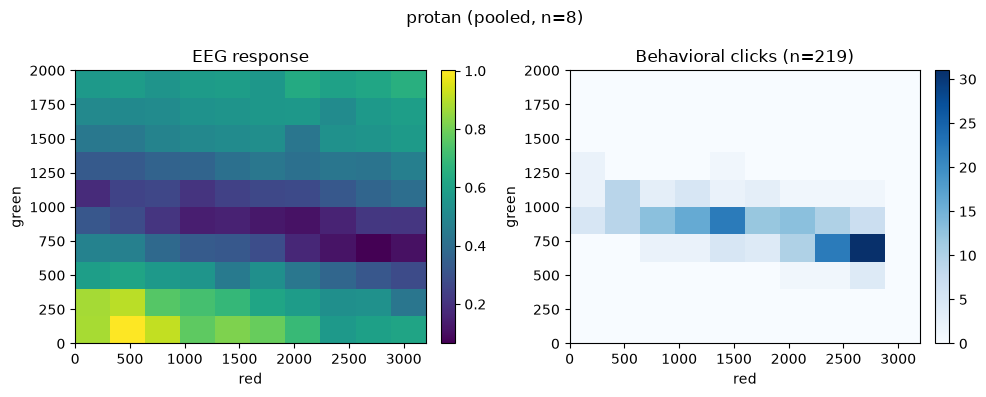

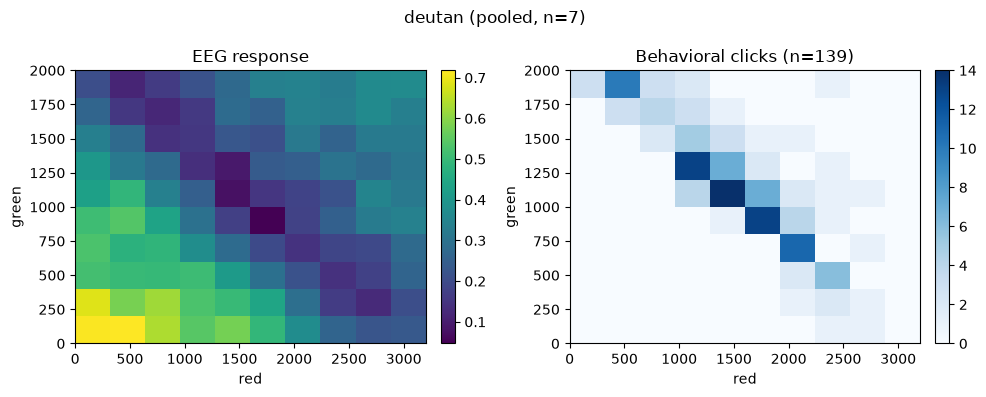

In [5]:
for label, kw in categories:
    sub_ids = overlap.analysis.subjects_in_group(metadata_df, session, **kw)
    E_group = analysis.mean_grid_across_subjects(runmap_df, baselines_df, sub_ids, session, normalize=analysis.DEFAULT_NORMALIZE)
    plotting.plot_overlap(beh_df, E_group, sub_ids, title=f'{label} (pooled, n={len(sub_ids)})')

## A second, simpler metric: behavioral centroid vs. EEG trough distance

Complements the density-overlap tests with one interpretable number per
subject: how far is a participant's mean behavioral click from their own
EEG trough location (argmin)?

In [6]:
rows = []
for sub_id in overlap_subs:
    r = overlap.centroid_distance(beh_df, runmap_df, baselines_df, sub_id, session)
    group = metadata_df.loc[(metadata_df['sub_id'] == sub_id) & (metadata_df['session'] == session), 'group'].iloc[0]
    rows.append({'sub_id': sub_id, 'group': group, **r})
distance_table = pd.DataFrame(rows)
distance_table.groupby('group')['distance'].agg(['count', 'mean', 'median'])

,count,mean,median
group,,,
CTR,21,421.672740,308.372353
CVD,15,788.780815,621.826752
HD,1,64.351412,64.351412
PD,6,406.478076,320.019747


CVD's behavioral-centroid-to-EEG-trough distance (mean ~789) is roughly
twice HC's (~422) and PD's (~406) -- consistent with CVD participants'
perceived color match diverging more from the EEG's minimal-response point,
plausibly because their own EEG trough estimate is less reliable to begin
with (`ssveps/`'s M6 finding that CVD trough fits are more likely to peg at
the sampled range boundary).

## 3. Individual-differences correlation: does EEG severity track behavioral severity?

The spatial tests above ask "do clicks land where EEG is low" -- they can
all be significant even if the two measures don't agree on *how bad* a
given subject's deficiency is relative to other subjects. This is the more
direct justification for using the EEG test clinically: if it's going to
stand in for (or complement) the behavioral/FM100 measures, its per-subject
severity should track theirs.

Behavioral features: centroid (`beh_red`, `beh_green`) and M2's PCA shape
features (`orientation_deg`, `along_var`, `perp_var`). EEG features: trough
location (`eeg_red`, `eeg_green`) and the M9-preferred, always-defined ramp
features (`ramp_slope_red`, `ramp_slope_green`, `ramp_intercept` -- the
latter a stand-in for M8's `gain`, r=-0.93 correlated with it) from
`ssveps/files/subject_troughs.csv`. Spearman (rank correlation), the same
robustness-to-small-n reasoning as M2's Mann-Whitney choice.

In [7]:
feature_table = correlation.subject_features_table(beh_df, session=session)
len(feature_table)

43

### Pooled across all groups (maximum range/power -- the whole clinical spectrum)

In [8]:
pooled_corr = correlation.feature_correlations(feature_table)
pooled_corr.sort_values('p_value').head(10)

,beh_feature,eeg_feature,r,p_value,n,group,subgroup
9,beh_green,ramp_intercept,-0.375113,0.013192,43,all,all
14,orientation_deg,ramp_intercept,-0.369224,0.014826,43,all,all
12,orientation_deg,ramp_slope_red,0.353368,0.020101,43,all,all
2,beh_red,ramp_slope_red,-0.350951,0.021029,43,all,all
4,beh_red,ramp_intercept,0.347629,0.022363,43,all,all
17,along_var,ramp_slope_red,0.340230,0.025591,43,all,all
16,along_var,eeg_green,-0.322400,0.034989,43,all,all
15,along_var,eeg_red,0.307346,0.044981,43,all,all
19,along_var,ramp_intercept,-0.274690,0.074642,43,all,all
5,beh_green,eeg_red,-0.215791,0.164597,43,all,all


**25 pairwise tests, uncorrected for multiple comparisons** -- read the
p-values as exploratory, not confirmatory (same caveat M8 used for its
single trough-residual test). With that caveat: `orientation_deg`
correlates with both `ramp_slope_red` (r=0.35, p=0.020) and
`ramp_intercept` (r=-0.37, p=0.015) -- the exact pairing motivated by M9's
reliability ranking and M2's cleanest behavioral signal. `beh_red` also
correlates with both ramp features (r=-0.35/0.35). Every top hit involves
either `orientation_deg`, `beh_red`, `beh_green`, or `along_var` against a
`ramp_*` feature -- `eeg_red`/`eeg_green` (the raw argmin location) and
`perp_var` show up nowhere near significance pooled.

### Per-group and per-subtype (does the relationship hold within a narrower severity range, not just across the HC-CVD gap?)

In [9]:
rows = []
for label, kw in categories:
    filt = {'group': kw.get('group'), 'subgroup': kw.get('subgroup')}
    r = correlation.feature_correlations(feature_table, **filt)
    top = r.loc[r['p_value'].idxmin()]
    rows.append({'category': label, 'n': top['n'], 'strongest_pair': f"{top['beh_feature']} vs {top['eeg_feature']}", 'r': top['r'], 'p_value': top['p_value']})
pd.DataFrame(rows)

,category,n,strongest_pair,r,p_value
0,HC,21,beh_red vs eeg_green,-0.417596,0.059619
1,PD,6,beh_red vs eeg_red,0.880406,0.020599
2,CVD,15,beh_red vs eeg_green,-0.663418,0.007011
3,protan,8,orientation_deg vs eeg_red,-0.601510,0.114684
4,deutan,7,beh_red vs eeg_green,-0.918956,0.003437


Two results stand out even at these small per-group n: **deutan's `beh_red` vs.
`eeg_green` is r=-0.92 (p=0.003, n=7)** and `beh_red` vs. `eeg_red` is
r=0.86 (p=0.012) -- within deutan alone, the EEG trough location tracks the
behavioral centroid almost perfectly. PD shows a similar pattern
(`beh_red` vs. `eeg_red`, r=0.88, p=0.021, n=6) despite n=6. Protan's
strongest pair (`orientation_deg` vs. `eeg_red`, r=-0.60) doesn't reach
significance at n=8. CTR's best pair (`beh_red` vs. `eeg_green`, r=-0.42)
is borderline (p=0.060, n=21) -- a trend, not a null result, in the largest
group here.

## Is this analysis enough?

**Not fully, but it's now a real answer instead of a single test.** What
the three checks together support:

- **Spatial overlap is real and robust** -- significant in every group, on
  two independently-constructed null models that agree completely. This
  part of the EEG test's validity is well established at this project's n.
- **Individual-differences convergence is present but partial and
  uncorrected.** The behavioral centroid's red coordinate tracks the EEG
  trough location strongly within deutan and PD, and `orientation_deg`
  (M2's cleanest protan-vs-deutan signal) correlates with the EEG's own
  most reliable feature (`ramp_slope_red`) pooled across groups -- but nothing
  here survives a multiple-comparisons correction, and protan and CTR alone
  don't reach significance on their own best pairing.

**What would make this fully "safe and sound":**

1. **Multiple-comparisons correction** (Holm/FDR across the 25-pair matrix)
   before treating any single pooled correlation as confirmed, not just
   exploratory.
2. **Cross-session reliability of the beh-EEG relationship itself** --
   still not built (see below): if `orientation_deg` vs. `ramp_slope_red`'s
   correlation isn't stable session-to-session, it's not a usable clinical
   signal even if today's p-value is real.
3. **More CVD/protan/deutan subjects** -- the same standing recommendation
   `ssveps/`'s own M6-M10 work has made throughout; n=7-8 per subtype is
   the binding constraint on every per-subgroup result here.

## Suggested further methods (not built this pass)

- **Cross-session reliability** -- for subjects with repeat sessions in
  both modalities, is the overlap/correlation relationship itself stable
  session to session (extends `ssveps/`'s M5/M9 reliability theme across
  modalities, and is the single most important gap per the assessment
  above)?
- **Multiple-comparisons-corrected correlation matrix** -- rerun
  `feature_correlations`' pooled result through Holm or Benjamini-Hochberg
  before reporting any pair as a confirmed finding.
- **Extend the correlation analysis to M8's `gain`/trough-region residual**
  once/if that pipeline is worth pulling into this project directly
  (currently stood in for by `ramp_intercept`, which correlates r=-0.93 with
  it).